In [1]:
from itertools import product
from typing import Any, Dict, Iterable
from datetime import datetime

from sklearn.metrics import mean_squared_error
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN
import pandas as pd
import numpy as np
import os
import re
import tensorflow as tf
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os

2025-04-05 10:47:47.574691: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-05 10:47:47.589673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743842867.602589    6063 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743842867.605686    6063 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-05 10:47:47.619032: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
NUM_SAMPLES = 300

config_base = load_config('configs/default.yaml')

fixed_points = {
        (0.0, 0.0) : "unstable", 
    } 
config = config_base
config["activation"] = "swish"
config["N_hidden"] = 4
config["N_neurons"] = 50
config["N_epochs"] = 25000
config["T"] = 12.5
config["freq_save"] = 0


version : default
seed : 1
alpha : -1.0
beta : 1.0
delta : 1.0
x0 : 0.2
x_t0 : 0.2
T : 12.5
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 250
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularizer : no_reg
reg_coeff : 0.0
reg_decay : linear
reg_epochs : 0.5


In [ ]:
x0s = np.random.normal(0, 0.25, size=NUM_SAMPLES)
x_t0s = np.random.normal(0, 0.25, size=NUM_SAMPLES)


plt.scatter(x0s, x_t0s)
plt.show()

dirname_no_reg = f"logs/models/visualization_experiments/no_reg"
if not os.path.exists(dirname_no_reg):
    os.makedirs(dirname_no_reg)

dirname_reg_derivative = f"logs/models/visualization_experiments/reg_derivative"
if not os.path.exists(dirname_reg_derivative):
    os.makedirs(dirname_reg_derivative)

dirname_reg_derivative_unstable_fp = f"logs/models/visualization_experiments/reg_derivative_unstable_fp"
if not os.path.exists(dirname_reg_derivative_unstable_fp):
    os.makedirs(dirname_reg_derivative_unstable_fp)

results_list = []

for i in range(NUM_SAMPLES):
    config["x0"] = float(x0s[i])
    config["x_t0"] = float(x_t0s[i])
    
    try:
        # Without regularization
        config["regularizer"] = "no_reg"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()

        PINN.save_weights(f"{dirname_no_reg}/run_{i}.pkl")

        t_line, x_true, x_t_true = PINN.data.reference()

        # get PINN prediction
        x_pred = PINN(t_line)
        loss = mean_squared_error(x_true.numpy(), x_pred.numpy())
        loss_success_no_reg = (np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)) < 0.15



        # With time derivative regularization
        config["regularizer"] = "reg_derivative"
        config["reg_coeff"] = 1.0
        config["reg_epochs"] = 0.5
        config["reg_decay"] = "linear"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()

        PINN.save_weights(f"{dirname_reg_derivative}/run_{i}.pkl")

        # get PINN prediction
        x_pred = PINN(t_line)
        loss = mean_squared_error(x_true.numpy(), x_pred.numpy())
        loss_success_reg_derivative = (np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)) < 0.15


        # With unstable fp regularization
        config["regularizer"] = "reg_derivative_unstable_fp"
        config["reg_coeff"] = 1.0
        config["reg_epochs"] = 0.5
        config["reg_decay"] = "linear"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()
        
        PINN.save_weights(f"{dirname_reg_derivative_unstable_fp}/run_{i}.pkl")
        
        # get PINN prediction
        x_pred = PINN(t_line)
        loss = mean_squared_error(x_true.numpy(), x_pred.numpy())
        loss_success_reg_derivative_unstable_fp = (np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)) < 0.15

        table_entry = pd.DataFrame({"(x0, x_t0)": [(float(x0s[i]), float(x_t0s[i]))], 
                                    "success_no_reg": [loss_success_no_reg],
                                    "success_reg_derivative": [loss_success_reg_derivative],
                                    "success_reg_derivative_unstable_fp": [loss_success_reg_derivative_unstable_fp]})
        
        results_list.append(table_entry)
        results_table = pd.concat(results_list)
        results_table.to_csv("visual_results.csv")

    except Exception as e:
        print(e)
            
     

In [4]:
plt.rcParams.update({'font.size': 12,
                     'axes.titlepad': 10,
                     'axes.titlesize': 14,
                     'axes.labelsize': 12,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })

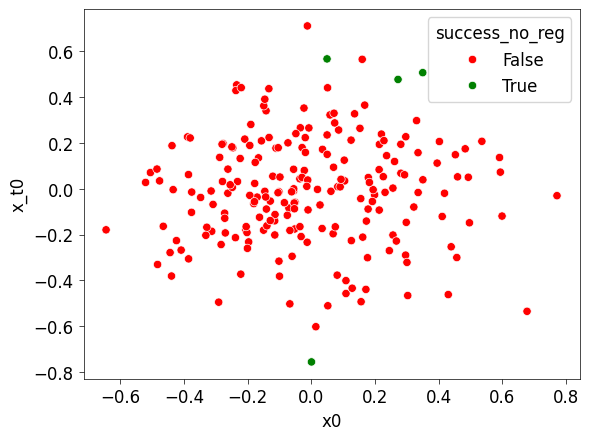

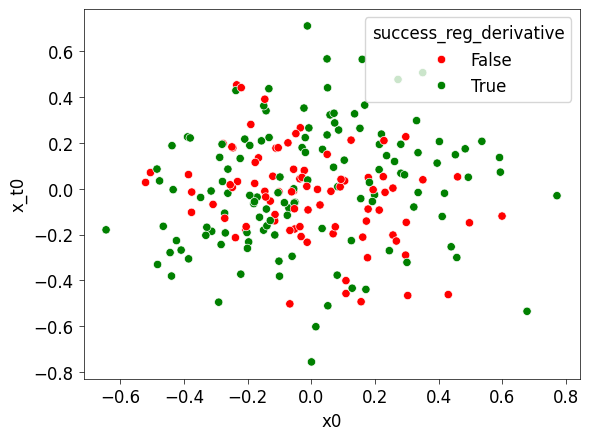

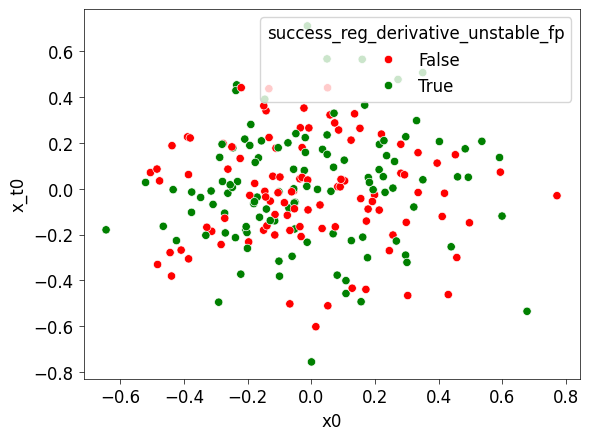

In [8]:
results_table = pd.read_csv("visual_results.csv")
results_table["x0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[0])
results_table["x_t0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}

plt.figure()
sns.scatterplot(data=results_table, x="x0", y="x_t0", hue="success_no_reg", palette=colors)
plt.show()

plt.figure()
sns.scatterplot(data=results_table, x="x0", y="x_t0", hue="success_reg_derivative", palette=colors)
plt.show()

plt.figure()
sns.scatterplot(data=results_table, x="x0", y="x_t0", hue="success_reg_derivative_unstable_fp", palette=colors)
plt.show()

/home/milos/Desktop/PINNs_fixed_points/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: CUDA error: Error recording CUDA event: CUDA_ERROR_LAUNCH_FAILED: unspecified launch failure

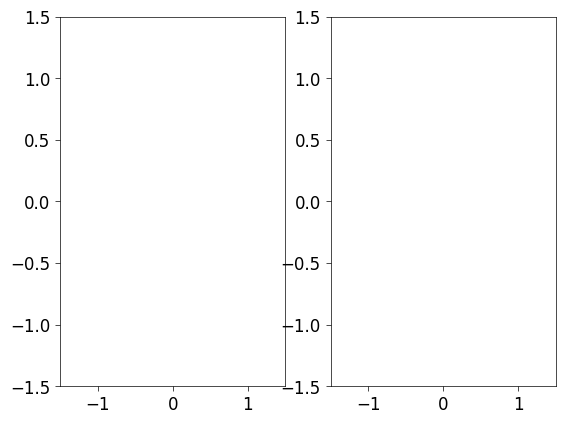

In [6]:
fig, axes = plt.subplots(1, 2)

results_table = pd.read_csv("visual_results.csv")
results_table["x0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[0])
results_table["x_t0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[1])

axes[0].set_xlim([-1.5, 1.5])
axes[0].set_ylim([-1.5, 1.5])

axes[1].set_xlim([-1.5, 1.5])
axes[1].set_ylim([-1.5, 1.5])

for i in range(50):
    config["x0"] = results_table["x0"].iloc[i]
    config["x_t0"] = results_table["x_t0"].iloc[i]
    PINN_no_reg = PhysicsInformedNN(config=config)
    PINN_no_reg.load_weights(f"{dirname_no_reg}/run_{i}.pkl")

    t_line, x_true, x_t_true = PINN_no_reg.data.reference()

    # get PINN prediction
    x_pred = PINN_no_reg(t_line)
    x_t_pred = PINN_no_reg.x_t(t_line)

    col = "green" if results_table["success_no_reg"].iloc[i] else "red"
    axes[0].plot(x_pred, x_t_pred, c=col)

    PINN_reg_derivative_unstable_fp = PhysicsInformedNN(config=config)
    PINN_reg_derivative_unstable_fp.load_weights(f"{dirname_reg_derivative_unstable_fp}/run_{i}.pkl")

    # get PINN prediction
    x_pred = PINN_reg_derivative_unstable_fp(t_line)
    x_t_pred = PINN_reg_derivative_unstable_fp.x_t(t_line)

    col = "green" if results_table["success_reg_derivative_unstable_fp"].iloc[i] else "red"
    axes[1].plot(x_pred, x_t_pred, c=col)

plt.show()